# Coreference Resolution + TextRank + BART Evaluation Pipeline
1. Coreference Resolution
2. TextRank
3. Base Pretrained BART Model

In [1]:
!pip install -r requirements.txt -q


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import os
from pathlib import Path
from tqdm import tqdm

In [3]:
# Check CUDA availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [4]:
import os
import logging
import warnings

# Disable Hugging Face progress bars (the 'Map' and 'Inference' bars)
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TQDM_DISABLE"] = "True"

# Suppress all logging from the libraries that fastcoref talks to
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("datasets").setLevel(logging.ERROR)
logging.getLogger("fastcoref").setLevel(logging.ERROR)

# Suppress the FutureWarnings from huggingface_hub
warnings.filterwarnings("ignore", category=FutureWarning)

## Import Dataset

In [5]:
import json

In [6]:
CWD         = os.getcwd()
DATA_PATH   = Path(CWD) / "data" / "all_v1.json"

In [7]:
with open(DATA_PATH, 'r') as f:
    json_str = f.read()
    data = json.loads(json_str)

## Coreference Resolution + TextRank

In [8]:
import spacy
import torch
import pytextrank
from fastcoref import FCoref
from fastcoref import spacy_component

d:\Documents\OneDrive - UTS\2026\42850 NLP Algorithms\Assignments\Assignment_2\NLP_Team5_Assignment3\venv\lib\site-packages


d:\Documents\OneDrive - UTS\2026\42850 NLP Algorithms\Assignments\Assignment_2\NLP_Team5_Assignment3\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0514 18:30:13.234000 63704 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


### Create Ablation Sets
We create separate datasets for each input sequence for the BART to summarize:
1. Raw unsummarized text from the dataset
2. Coreference resolution on the corpus
3. TextRank filter on the corpus
4. Coreference resolution + TextRank filter on the corpus

In [9]:
import pandas as pd

In [10]:
ABLATION_PATH   = Path(CWD) / "data" / "ablation"

os.makedirs(name=ABLATION_PATH, exist_ok=True)

In [11]:
# Convert the dictionary values into a list of dicts
rows = list(data.values())
cols = ["doc", "original_text", "reference_summary"]

# Create dataframe
df = pd.DataFrame(rows)[cols]

# Export to CSV
df.to_csv(ABLATION_PATH / "raw.csv", index=False)

In [12]:
# Coreference resolution on corpus
df = pd.read_csv(ABLATION_PATH / "raw.csv")
nlp = spacy.load("en_core_web_sm")

nlp.add_pipe("fastcoref")

for i, row in df.iterrows():
    doc = nlp(row['original_text'], component_cfg={"fastcoref":{"resolve_text": True}})
    for k in doc._.coref_clusters:
        print([row['original_text'][start:end] for start, end in k])

    df.loc[i, "original_text"] = doc._.resolved_text

df.to_csv(ABLATION_PATH / "coref.csv", index=False)


Inference: 100%|██████████| 1/1 [00:01<00:00,  1.26s/it]


['these pokémon go terms of service', 'the terms', 'these terms']
['the niantic inc niantic mobile device application the app', 'the app']
['our', 'our', 'our', 'our', 'our']
['our trainer guidelines and our privacy policy', 'they']
['our video game services', 'our services']


Inference: 100%|██████████| 1/1 [00:00<00:00, 124.99it/s]


['our', 'our', 'our', 'our', 'our', 'our']
['these terms', 'these terms', 'these terms', 'these terms']
['yourself', 'your']
['our services', 'the services', 'the services']
['our privacy policy', 'our privacy policy', 'our privacy policy']


Inference: 100%|██████████| 1/1 [00:00<00:00, 36.37it/s]


...

['we', 'we', 'we', 'our', 'our']


Inference: 100%|██████████| 1/1 [00:00<00:00, 153.85it/s]


['we', 'we']


Inference: 100%|██████████| 1/1 [00:00<00:00, 181.85it/s]

['revised terms', 'the changes']


### TextRank Sentence Score
TextRank builds a graph of phrases based on their co-occurrence. Each phrase is scored based on the **Phrase Rank** algorithm. Once every key phrase in the document has a rank, we aggregate the ranks of phrases occurring in any given sentence $S$ to determine the value of that sentence.

$$sentence \space score(S) = \sum_{p \in Phrases(S)} Rank(p) \times Weight(p, S)$$

The magnitude of the sentence score is a measure of information density and centrality (relevance to other phrases).
- A high magnitude indicates that the sentence acts as a hub for the document's main ideas.
- A low magnitude might indicate "filler" or transitionary (e.g., "in addition to this..." or "Finally, we conclude..."). These sentences often contain common words but few ranked phrases.

In [13]:
# TextRank on corpus
df = pd.read_csv(ABLATION_PATH / "raw.csv")

nlp = spacy.load("en_core_web_sm")
nlp.add_pipe("textrank")

PARETO_THRESHOLD = 0.8  # Aim ffor the top sentences that make up 80% of the total score

for i, row in df.iterrows():
    doc = nlp(row['original_text'])
    phrases = doc._.phrases

    # 1. Collect all sentences and their scores into a list of dictionaries
    scored_sentences    = []
    total_doc_score     = 0

    print(f"Document: {i}")
    print(f"Summary: {row['reference_summary']}")
    for sent in doc.sents:
        # Define weight_p_s as the count of phrase chunks within sentence boundaries
        # Define rank_p_s as each phrases pagerank score
        # Calculate score: sum of ranks of phrases that appear in this sentence
        weight_p_s  = [sum(1 for chunk in p.chunks if chunk.start >= sent.start and chunk.end <= sent.end) for p in phrases]
        rank_p_s    = [p.rank for p in phrases]
        sent_score = sum(rank*weight for rank, weight in zip(rank_p_s, weight_p_s))

        scored_sentences.append({
            'sent': sent,
            'score': sent_score,
            'index': sent.start # Keep track of original order
        })
        total_doc_score += sent_score

    # 2. Sort sentences by score in descending order
    scored_sentences.sort(key=lambda x: x['score'], reverse=True)

    # 3. Apply Parento selection
    selected_sentences  = []
    cumulative_score    = 0

    for item in scored_sentences:
        if total_doc_score == 0: break  # Handle empty/low-signal docs

        selected_sentences.append(item)
        cumulative_score += item['score']

        # Stop once we've reached the threshold of the total information weight
        if (cumulative_score / total_doc_score) >= PARETO_THRESHOLD:
            break

    # 4. Sort selected sentences back into their original document order to maintain narrative flow for BART/LSTM
    selected_sentences.sort(key=lambda x: x['index'])

    # Reconstructed text
    recon_text  = ' '.join([item['sent'].text for item in selected_sentences])

    # Compare the sentences before and after TextRank processing
    for item in selected_sentences:
        print(f"[{item['score']:.4f}] {item['sent'].text}")

    print(len(row['original_text']), len(recon_text))

    df.loc[i, "original_text"] = recon_text

df.to_csv(ABLATION_PATH / "textrank.csv", index=False)

Document: 0
Summary: hi.
[0.4530] welcome to the pokémon go video game services which are accessible via the niantic inc niantic mobile device application the app.
[0.9018] to make these pokémon go terms of service the terms easier to read our video game services the app and our websites located at http pokemongo nianticlabs com and http www pokemongolive com the site are collectively called the services.
491 365
Document: 1
Summary: by playing this game you agree to these terms. if you re under 13 and playing your parent guardian agrees on your behalf.
[0.8375] if you are the parent or legal guardian of a child under the age of 13 the parent you are agreeing to these terms on behalf of yourself and your child ren who are authorized to use the services pursuant to these terms and in our privacy policy.
[0.4735] if you don t agree to these terms our trainer guidelines and our privacy policy do not use the services.
450 349
Document: 2
Summary: you have to use google pokemon trainer club

In [14]:
# TextRank on corpus
df = pd.read_csv(ABLATION_PATH / "raw.csv")

nlp = spacy.load("en_core_web_sm")
nlp.add_pipe(
    "fastcoref",
    config={
        "enable_progress_bar": False # Configure it here instead
    }
)
nlp.add_pipe("textrank")

PARETO_THRESHOLD    = 0.8  # Aim for the top sentences that make up 80% of the total score
resolved_texts      = []

# BATCHED Coreference Resolution
docs = nlp.pipe(
    df['original_text'].astype(str).tolist(),
    batch_size=8,
    disable=["textrank"],
    component_cfg={"fastcoref": {"resolve_text": True}}
)

for doc in docs:
    resolved_texts.append(doc._.resolved_text)

df['resolved_text'] = resolved_texts


for i, row in df.iterrows():
    # TextRank only
    doc = nlp(
        row['resolved_text'],
        disable=["fastcoref"]
    )
    phrases = doc._.phrases

    # 1. Collect all sentences and their scores into a list of dictionaries
    scored_sentences    = []
    total_doc_score     = 0

    print(f"Document: {i}")
    print(f"Summary: {row['reference_summary']}")
    for sent in doc.sents:
        # Define weight_p_s as the count of phrase chunks within sentence boundaries
        # Define rank_p_s as each phrases pagerank score
        # Calculate score: sum of ranks of phrases that appear in this sentence
        weight_p_s  = [sum(1 for chunk in p.chunks if chunk.start >= sent.start and chunk.end <= sent.end) for p in phrases]
        rank_p_s    = [p.rank for p in phrases]
        sent_score = sum(rank*weight for rank, weight in zip(rank_p_s, weight_p_s))

        scored_sentences.append({
            'sent': sent,
            'score': sent_score,
            'index': sent.start # Keep track of original order
        })
        total_doc_score += sent_score

    # 2. Sort sentences by score in descending order
    scored_sentences.sort(key=lambda x: x['score'], reverse=True)

    # 3. Apply Parento selection
    selected_sentences  = []
    cumulative_score    = 0

    for item in scored_sentences:
        if total_doc_score == 0: break  # Handle empty/low-signal docs

        selected_sentences.append(item)
        cumulative_score += item['score']

        # Stop once we've reached the threshold of the total information weight
        if (cumulative_score / total_doc_score) >= PARETO_THRESHOLD:
            break

    # 4. Sort selected sentences back into their original document order to maintain narrative flow for BART/LSTM
    selected_sentences.sort(key=lambda x: x['index'])

    # Reconstructed text
    recon_text  = ' '.join([item['sent'].text for item in selected_sentences])

    # Compare the sentences before and after TextRank processing
    for item in selected_sentences:
        print(f"[{item['score']:.4f}] {item['sent'].text}")

    print(len(row['original_text']), len(recon_text))

    df.loc[i, "original_text"] = recon_text

df = df.drop(columns=['resolved_text'])
df.to_csv(ABLATION_PATH / "coref+tr.csv", index=False)

Map: 100%|██████████| 6/6 [00:00<00:00, 545.46 examples/s]


Document: 0
Summary: hi.
[0.4840] welcome to the pokémon go video game services which are accessible via the niantic inc niantic mobile device application the app.
[1.3217] to make these pokémon go terms of service these pokémon go terms of service easier to read our video game services the niantic inc niantic mobile device application the app and our websites located at http pokemongo nianticlabs com and http www pokemongolive com the site are collectively called the services.
[0.5995] please read carefully these pokémon go terms of service our trainer guidelines and our privacy policy because our trainer guidelines and our privacy policy govern your use of our services.
491 628
Document: 1
Summary: by playing this game you agree to these terms. if you re under 13 and playing your parent guardian agrees on your behalf.
[0.8375] if you are the parent or legal guardian of a child under the age of 13 the parent you are agreeing to these terms on behalf of yourself and your child ren who 

## Pretrained BART

In [12]:
from tqdm import tqdm
from transformers import BartTokenizer, BartForConditionalGeneration
import matplotlib.pyplot as plt

In [13]:
MODEL_PATH  = Path(CWD) / "models"
LOSS_PATH   = Path(CWD) / "loss_curves"

os.makedirs(name=MODEL_PATH, exist_ok=True)
os.makedirs(name=LOSS_PATH, exist_ok=True)

base_dir        = "bart_model"
fine_dir        = "fine_model"
coref_dir       = "coref_model"
textrank_dir    = "textrank_model"
coref_tr_dir    = "coref+tr_model"

base_path       = MODEL_PATH / base_dir
fine_path       = MODEL_PATH / fine_dir
coref_path      = MODEL_PATH / coref_dir
textrank_path   = MODEL_PATH / textrank_dir
coref_tr_path   = MODEL_PATH / coref_tr_dir

In [14]:
# Reload the locally saved model
base_tokenizer   = BartTokenizer.from_pretrained(base_path)
base_model       = BartForConditionalGeneration.from_pretrained(base_path)

# Load initialize all models as the base model for fine tuning
fine_model      = BartForConditionalGeneration.from_pretrained(base_path)
# coref_model     = BartForConditionalGeneration.from_pretrained(base_path)
# textrank_model  = BartForConditionalGeneration.from_pretrained(base_path)
# coref_tr_model  = BartForConditionalGeneration.from_pretrained(base_path)

## Fine-Tuning

In [15]:
def preprocess_function(examples):
    # Tokenize the source text (Original)
    model_inputs = base_tokenizer(
        examples["original_text"], 
        max_length=1024, 
        truncation=True, 
        padding="max_length"
    )

    # Tokenize the target text (Summary)
    labels = base_tokenizer(
        text_target=examples["reference_summary"], 
        max_length=128, 
        truncation=True, 
        padding="max_length"
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [16]:
def plot_loss(history, meta):
    train_loss = [log["loss"] for log in history if "loss" in log]
    train_steps = [log["step"] for log in history if "loss" in log]

    val_loss = [log["eval_loss"] for log in history if "eval_loss" in log]
    val_steps = [log["step"] for log in history if "eval_loss" in log]

    # Create Plot
    plt.figure(figsize=(10, 6))
    plt.plot(train_steps, train_loss, label="Training Loss", color="blue", alpha=0.6)
    plt.plot(val_steps, val_loss, label="Validation Loss", color="red", marker='o')

    plt.title(meta['title'])
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    # Save the plot for your UTS report
    plt.savefig(meta['loss_path'])
    plt.show()

In [17]:
from datasets import Dataset
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq, EarlyStoppingCallback

In [18]:
models = {
    "fine":{
        "model":fine_model,
        "save_path":str(fine_path),
        "title":"BART Fine-Tuning: Training vs Validation Loss",
        "trainer":None,
        "csv":ABLATION_PATH / "raw.csv",
        "loss_path": LOSS_PATH / "fine"
    }
}

In [19]:
output_dir                  = MODEL_PATH        # Where to save the fine-tuned model
evaluation_strategy         = "epoch"
eval_steps                  = 1                 # Evaluate every step
logging_strategy            = "epoch"
learning_rate               = 2e-5              # Typical for BART fine-tuning
per_device_train_batch_size = 4                 # Adjust based on your GPU VRAM
per_device_eval_batch_size  = 4
weight_decay                = 0.01
save_total_limit            = 2
num_train_epochs            = 32                # 3-5 epochs is usually enough for summarization
predict_with_generate       = False             # Required for ROUGE evaluation
fp16                        = True              # Use Mixed Precision if on GPU
report_to                   = "none"            # Set to "wandb" if you use weights & biases
save_strategy               = "epoch"
save_steps                  = 1
load_best_model_at_end      = True              # Load the best weights when finished
metric_for_best_model       = "loss"            # Use validation loss to fine the best model
greater_is_better           = False             # Lower loss is better
early_stopping_patience     = 3

In [37]:
for name, meta in models.items():
    # Load dataset according to ablation
    dataframe   = pd.read_csv(meta['csv'])
    dataset     = Dataset.from_pandas(dataframe[['original_text', 'reference_summary']])

    # Tokenize and split the dataset
    tokenized_dataset = dataset.map(preprocess_function, batched=True)
    tokenized_dataset = tokenized_dataset.train_test_split(test_size=0.1)

    # Training loop
    training_args = Seq2SeqTrainingArguments(
        output_dir=output_dir,
        evaluation_strategy=evaluation_strategy,
        eval_steps=eval_steps,
        logging_strategy=logging_strategy,
        learning_rate=learning_rate,
        per_device_train_batch_size=per_device_train_batch_size,
        per_device_eval_batch_size=per_device_eval_batch_size,
        weight_decay=weight_decay,
        save_total_limit=save_total_limit,
        num_train_epochs=num_train_epochs,
        predict_with_generate=predict_with_generate,
        fp16=fp16,
        report_to=report_to,
        save_strategy=save_strategy,
        save_steps=save_steps,
        load_best_model_at_end=load_best_model_at_end,
        metric_for_best_model=metric_for_best_model,
        greater_is_better=greater_is_better
    )

    data_collator = DataCollatorForSeq2Seq(base_tokenizer, model=meta['model'])

    trainer = Seq2SeqTrainer(
        model=meta['model'],
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["test"],
        tokenizer=base_tokenizer,
        data_collator=data_collator,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=early_stopping_patience)]
    )

    trainer.train() 
    trainer.save_model(str(meta['save_path']))
    meta['trainer'] = trainer

  3%|▎         | 101/3232 [00:19<08:57,  5.82it/s]

{'loss': 1.9051, 'learning_rate': 1.9399752475247526e-05, 'epoch': 1.0}


                                                  
  3%|▎         | 101/3232 [00:20<08:57,  5.82it/s]Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0, 'forced_eos_token_id': 2}


{'eval_loss': 0.3487708866596222, 'eval_runtime': 0.485, 'eval_samples_per_second': 92.784, 'eval_steps_per_second': 24.742, 'epoch': 1.0}


  6%|▋         | 202/3232 [00:49<08:42,  5.80it/s]  

...

{'loss': 0.0466, 'learning_rate': 1.6899752475247526e-05, 'epoch': 5.0}


                                                  
 16%|█▌        | 505/3232 [02:59<07:24,  6.14it/s]Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0, 'forced_eos_token_id': 2}


{'eval_loss': 0.38035640120506287, 'eval_runtime': 0.493, 'eval_samples_per_second': 91.278, 'eval_steps_per_second': 24.341, 'epoch': 5.0}


There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].
 16%|█▌        | 505/3232 [03:27<18:38,  2.44it/s]
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0, 'forced_eos_token_id': 2}


{'train_runtime': 207.1386, 'train_samples_per_second': 61.949, 'train_steps_per_second': 15.603, 'train_loss': 0.48408862293356714, 'epoch': 5.0}


In [26]:
# Reload 
models['fine']['model'] = BartForConditionalGeneration.from_pretrained(models['fine']['save_path'])
fine_model = models['fine']['model']

In [27]:
# Coreference resolution on corpus
df = pd.read_csv(ABLATION_PATH / "coref+tr.csv")
z = 3
text = df.loc[z, "original_text"]
target = df.loc[z, "reference_summary"]

inputs = base_tokenizer(
    text,
    return_tensors="pt",
    max_length=1024,
    truncation=True
)

# 2. MOVE INPUTS TO GPU <--- This is the missing step
# We move every tensor in the dictionary (input_ids, attention_mask) to CUDA
base_inputs = {k: v.to(base_model.device) for k, v in inputs.items()}
fine_inputs = {k: v.to(fine_model.device) for k, v in inputs.items()}

summary_base = base_model.generate(
    base_inputs["input_ids"],
    max_length=100,
    min_length=30,
    length_penalty=2.0,
    num_beams=4,
    early_stopping=True
)

summary_fine = fine_model.generate(
    fine_inputs["input_ids"],
    max_length=100,
    min_length=30,
    length_penalty=2.0,
    num_beams=4,
    early_stopping=True
)

base_summary = base_tokenizer.decode(summary_base[0], skip_special_tokens=True)
fine_summary = base_tokenizer.decode(summary_fine[0], skip_special_tokens=True)

print("Summary:")
print("  Original -", text)
print("  Base Resolved -", base_summary)
print("  Fine Resolved -", fine_summary)
print("  Target -", target)

Summary:
  Original - you also agree not to use the app to violate any applicable law rule or regulation including but not limited to the laws of trespass or the trainer guidelines and you agree not to encourage or enable any other individual to violate any applicable law rule or regulation or the trainer guidelines. without limiting the foregoing you agree that in conjunction with your use of the app you will not inflict emotional distress on other people will not humiliate other people publicly or otherwise will not assault or threaten other people will not enter onto private property without permission will not impersonate any other person or misrepresent your affiliation title or authority and will not otherwise engage in any activity that may result in injury death property damage and or liability of any kind. to the extent permitted by applicable law niantic the pokémon company tpc and tpci disclaim all liability related to any property damage personal injury or death that may oc

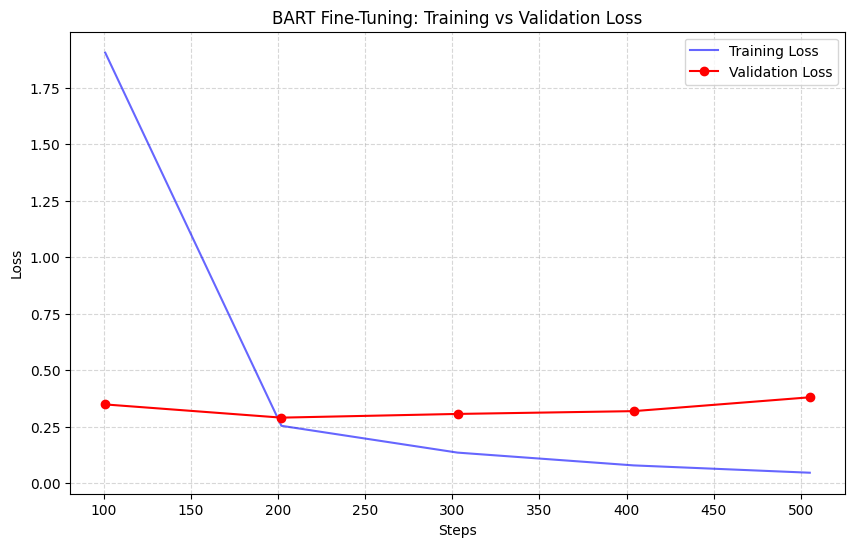

In [41]:
for name, meta in models.items():
    history = meta['trainer'].state.log_history
    title   = meta['title']

    plot_loss(history=history, meta=meta)

## NOTES:
- We only fine-tune the BART model off of the raw input text.
  - Adding coreference resolution to the pipeline makes it such that the input sentences are grammatically & syntactically uncanny. This leads the model to have to greatly modify its weights to align with the input sequence.
  - In some cases, the model can fail to produce an end of sentence token (repetition in generated tokens e.g., these services these services these services...)

# Model Distillation
This section aims to distill the base model and our fine-tuned BART models into smaller transformer architectures.

In [20]:
from tqdm import tqdm
from transformers import BartConfig, BartTokenizer, BartForConditionalGeneration
import matplotlib.pyplot as plt
import os
import copy

In [21]:
from datasets import Dataset
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq, EarlyStoppingCallback

In [22]:
MODEL_PATH  = Path(CWD) / "models"
LOSS_PATH   = Path(CWD) / "loss_curves"

os.makedirs(name=MODEL_PATH, exist_ok=True)
os.makedirs(name=LOSS_PATH, exist_ok=True)

base_dir        = "bart_model"
fine_dir        = "fine_model"
student_a_dir   = "student_a_model"
student_b_dir   = "student_b_model"

base_path       = MODEL_PATH / base_dir
fine_path       = MODEL_PATH / fine_dir
student_a_path  = MODEL_PATH / student_a_dir
student_b_path  = MODEL_PATH / student_b_dir

In [23]:
os.makedirs(student_a_path, exist_ok=True)
os.makedirs(student_b_path, exist_ok=True)

In [24]:
# Check CUDA availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [24]:
models = {
    "base":{
        "model":None,
        "save_path":str(base_path),
        "title":"BART: Training vs Validation Loss",
        "trainer":None,
        "csv":ABLATION_PATH / "raw.csv",
        "loss_path":LOSS_PATH / "base"
    },
    "fine":{
        "model":None,
        "save_path":str(fine_path),
        "title":"BART Fine-Tuning: Training vs Validation Loss",
        "trainer":None,
        "csv":ABLATION_PATH / "raw.csv",
        "loss_path":LOSS_PATH / "fine"
    },
    "student_a":{
        "model":None,
        "save_path":str(student_a_path),
        "title":"Fine Distil: Training vs Validation Loss",
        "csv":ABLATION_PATH / "raw.csv",
        "loss_path":LOSS_PATH / "student_a"
    },
        "student_b":{
        "model":None,
        "save_path":str(student_b_path),
        "title":"Fine Distil: Training vs Validation Loss",
        "csv":ABLATION_PATH / "raw.csv",
        "loss_path":LOSS_PATH / "student_b"
    }
}

In [25]:
# Reload 
base_tokenizer   = BartTokenizer.from_pretrained(base_path)

models['base']['model'] = BartForConditionalGeneration.from_pretrained(base_path)
models['fine']['model'] = BartForConditionalGeneration.from_pretrained(models['fine']['save_path'])

base_model = models['base']['model']
fine_model = models['fine']['model']

### Distillation Parameters
The original BART large model uses 12 encoder-decoder layers. Reducing to 6/6 is essentially a half-depth compression strategy.

| Model     | Encoder   | Decoder   | Notes                     |
|-----------|-----------|-----------|---------------------------|
| Teacher   | 12        | 12        | Baseline                  |
| Student A | 6         | 6         | Balanced comprehension    |
| Student B | 12        | 6         | Preserve comprehension    |

In [26]:
# Student A
teacher = fine_model

student_config = copy.deepcopy(teacher.config)
student_config.encoder_layers = 6
student_config.decoder_layers = 6

student = BartForConditionalGeneration(student_config)

In [27]:
# Copy shared embeddings
student.model.encoder.embed_tokens.weight.data = (teacher.model.encoder.embed_tokens.weight.data.clone())
student.model.decoder.embed_tokens.weight.data = (teacher.model.decoder.embed_tokens.weight.data.clone())
student.model.encoder.embed_positions.weight.data = (teacher.model.encoder.embed_positions.weight.data.clone())
student.model.decoder.embed_positions.weight.data = (teacher.model.decoder.embed_positions.weight.data.clone())

student.model.encoder.layernorm_embedding.load_state_dict(teacher.model.encoder.layernorm_embedding.state_dict())
student.model.decoder.layernorm_embedding.load_state_dict(teacher.model.decoder.layernorm_embedding.state_dict())

student.model.shared.weight.data = (teacher.model.shared.weight.data.clone())
student.lm_head.weight.data = (teacher.lm_head.weight.data.clone())
student.final_logits_bias.data = (teacher.final_logits_bias.data.clone())

In [28]:
# Copy encoder layers
teacher_encoder_layers = teacher.model.encoder.layers
student_encoder_layers = student.model.encoder.layers

selected = [0, 2, 4, 6, 8, 10]

for s_idx, t_idx in enumerate(selected):
    student_encoder_layers[s_idx].load_state_dict(teacher_encoder_layers[t_idx].state_dict())

# Copy decoder layers
teacher_decoder_layers = teacher.model.decoder.layers
student_decoder_layers = student.model.decoder.layers

selected = [0, 2, 4, 6, 8, 10]

for s_idx, t_idx in enumerate(selected):
    student_decoder_layers[s_idx].load_state_dict(teacher_decoder_layers[t_idx].state_dict())

In [29]:
student.save_pretrained(student_a_path)
base_tokenizer.save_pretrained(student_a_path)

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0, 'forced_eos_token_id': 2}


('d:\\Documents\\OneDrive - UTS\\2026\\42850 NLP Algorithms\\Assignments\\Assignment_2\\NLP_Team5_Assignment3\\models\\student_a_model\\tokenizer_config.json',
 'd:\\Documents\\OneDrive - UTS\\2026\\42850 NLP Algorithms\\Assignments\\Assignment_2\\NLP_Team5_Assignment3\\models\\student_a_model\\special_tokens_map.json',
 'd:\\Documents\\OneDrive - UTS\\2026\\42850 NLP Algorithms\\Assignments\\Assignment_2\\NLP_Team5_Assignment3\\models\\student_a_model\\vocab.json',
 'd:\\Documents\\OneDrive - UTS\\2026\\42850 NLP Algorithms\\Assignments\\Assignment_2\\NLP_Team5_Assignment3\\models\\student_a_model\\merges.txt',
 'd:\\Documents\\OneDrive - UTS\\2026\\42850 NLP Algorithms\\Assignments\\Assignment_2\\NLP_Team5_Assignment3\\models\\student_a_model\\added_tokens.json')

## Distillation Training

In [30]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import AdamW
from tqdm import tqdm

In [31]:
def distillation_loss(student_logits, teacher_logits, labels, alpha=0.5, temperature=2.0 ):
    """
    Combined:
        - Cross Entropy Loss
        - KL Divergence Distillation Loss
    """
    # Hard target loss
    vocab_size = student_logits.size(-1)
    ce_loss = F.cross_entropy(student_logits.view(-1, vocab_size), labels.view(-1), ignore_index=-100)

    # Soft target loss
    student_log_probs = F.log_softmax(student_logits / temperature, dim=-1)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=-1)
    kd_loss = F.kl_div(student_log_probs, teacher_probs, reduction="batchmean") * (temperature ** 2)

    # Total loss
    total_loss = (alpha * ce_loss + (1 - alpha) * kd_loss)

    return total_loss, ce_loss, kd_loss

In [32]:
def evaluate_student(student_model, teacher_model, test_loader, alpha, temperature):
    student_model.eval()
    total_test_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Validation"):

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # Forward passes for both student and teacher models
            teacher_outputs = teacher_model(input_ids=input_ids,attention_mask=attention_mask,labels=labels)
            student_outputs = student_model(input_ids=input_ids,attention_mask=attention_mask,labels=labels)

            # Compute distillation loss
            loss, _, _ = distillation_loss(
                student_outputs.logits,
                teacher_outputs.logits,
                labels,
                alpha=alpha,
                temperature=temperature
            )

            total_test_loss += loss.item()

    avg_test_loss = total_test_loss / len(test_loader)

    student_model.train()

    return avg_test_loss

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [34]:
# Distillation hyperparameters
EPOCHS = 500
PATIENCE = 20

LEARNING_RATE = 1e-4
ALPHA = 0.5          # balance between CE and KD
TEMPERATURE = 2.0

optimizer = AdamW(student.parameters(), lr=LEARNING_RATE)

In [35]:
# Tokenization hyperparameters
MAX_INPUT   = 1024
MAX_TARGET  = 256


In [36]:
def preprocess(example):
    model_inputs = base_tokenizer(example["original_text"], max_length=MAX_INPUT, truncation=True)
    labels = base_tokenizer(text_target=example["reference_summary"], max_length=MAX_TARGET, truncation=True)
    labels_ids = labels["input_ids"]

    labels_ids = [
        [
            token if token != base_tokenizer.pad_token_id else -100
            for token in label
        ]
        for label in labels_ids
    ]

    model_inputs["labels"] = labels_ids

    return model_inputs

In [37]:
# Load dataset according to ablation
dataframe   = pd.read_csv(ABLATION_PATH / "raw.csv")
dataset     = Dataset.from_pandas(dataframe[['original_text', 'reference_summary']])

data_collator   = DataCollatorForSeq2Seq(base_tokenizer, model=teacher, padding=True)

dataset_split   = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset   = dataset_split['train']
test_dataset    = dataset_split['test']

tokenized_train = train_dataset.map(preprocess, batched=True)
tokenized_test  = test_dataset.map(preprocess, batched=True)

tokenized_train = tokenized_train.remove_columns(["original_text", "reference_summary"])
tokenized_test = tokenized_test.remove_columns(["original_text", "reference_summary"])

tokenized_train.set_format("torch")
tokenized_test.set_format("torch")

train_loader = DataLoader(
    tokenized_train,
    batch_size=4,
    shuffle=True,
    collate_fn=data_collator
)

test_loader = DataLoader(
    tokenized_test,
    batch_size=4,
    shuffle=False,
    collate_fn=data_collator
)

Map: 100%|██████████| 90/90 [00:00<00:00, 1956.52 examples/s]


In [38]:
teacher.to(device)
student.to(device)

# Teacher should NEVER update during distillation
teacher.eval()

optimizer = AdamW(student.parameters(), lr=1e-4)

In [39]:
best_test_loss      = float("inf")
patience_counter    = 0
train_history       = []
test_history        = []

for epoch in range(EPOCHS):

    print(f"\n==============================")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"==============================")

    student.train()
    total_train_loss = 0.0
    progress_bar = tqdm(train_loader, desc="Training")

    for batch in progress_bar:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        # Model outputs
        with torch.no_grad():
            teacher_outputs = teacher(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        student_outputs = student(input_ids=input_ids,attention_mask=attention_mask,labels=labels)

        # Distillation loss
        loss, ce_loss, kd_loss = distillation_loss(
            student_outputs.logits,
            teacher_outputs.logits,
            labels,
            alpha=ALPHA,
            temperature=TEMPERATURE
        )

        # Backpropagation
        loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(),max_norm=1.0)
        optimizer.step()
        total_train_loss += loss.item()

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "ce": f"{ce_loss.item():.4f}",
            "kd": f"{kd_loss.item():.4f}"
        })

    # Training and testing
    avg_train_loss = total_train_loss / len(train_loader)
    print(f"\nAverage Train Loss: {avg_train_loss:.4f}")

    avg_test_loss = evaluate_student(
        student_model=student, 
        teacher_model=teacher, 
        test_loader=test_loader, 
        alpha=ALPHA, 
        temperature=TEMPERATURE
    )
    print(f"Testing Loss: {avg_test_loss:.4f}")

    train_history.append(avg_train_loss)
    test_history.append(avg_test_loss)

    # Early stopping
    if avg_test_loss < best_test_loss:
        print("Validation improved — saving model.")

        best_test_loss = avg_test_loss
        patience_counter = 0

        student.save_pretrained(student_a_path)
        base_tokenizer.save_pretrained(student_a_path)

    else:
        patience_counter += 1

        print(
            f"No improvement. "
            f"Patience: {patience_counter}/{PATIENCE}"
        )

        if patience_counter >= PATIENCE:
            print("\nEarly stopping triggered.")
            break


Epoch 1/500


Training: 100%|██████████| 89/89 [00:09<00:00,  9.22it/s, loss=21.5638, ce=2.5199, kd=40.6078] 



Average Train Loss: 42.3089


Validation: 100%|██████████| 23/23 [00:01<00:00, 21.62it/s]
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0, 'forced_eos_token_id': 2}


Testing Loss: 29.1234
Validation improved — saving model.

Epoch 2/500


...

Testing Loss: 7.6819
No improvement. Patience: 19/20

Epoch 83/500


Training: 100%|██████████| 89/89 [00:09<00:00,  9.71it/s, loss=1.5204, ce=0.4080, kd=2.6328]



Average Train Loss: 1.6969


Validation: 100%|██████████| 23/23 [00:01<00:00, 21.31it/s]

Testing Loss: 7.7421
No improvement. Patience: 20/20

Early stopping triggered.


In [40]:
import matplotlib.pyplot as plt

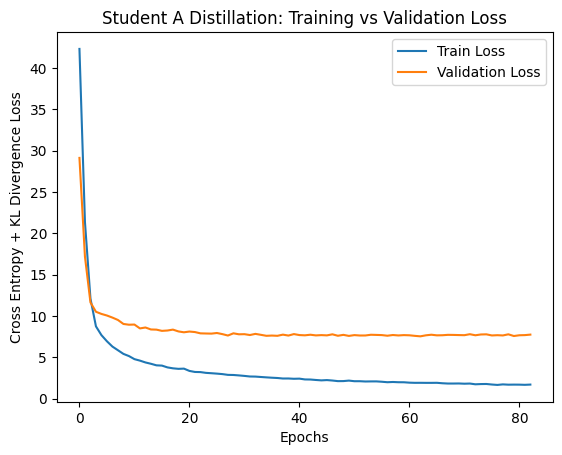

In [41]:
plt.plot(train_history, label="Train Loss")
plt.plot(test_history, label="Validation Loss")
plt.title("Student A Distillation: Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Cross Entropy + KL Divergence Loss")
plt.legend()
plt.show()

In [42]:
# Student B
teacher = fine_model

# Student A
teacher = fine_model

student_config = copy.deepcopy(teacher.config)
student_config.encoder_layers = 12
student_config.decoder_layers = 6

student = BartForConditionalGeneration(student_config)

student = BartForConditionalGeneration(student_config)

# Copy shared embeddings
student.model.encoder.embed_tokens.weight.data = (teacher.model.encoder.embed_tokens.weight.data.clone())
student.model.decoder.embed_tokens.weight.data = (teacher.model.decoder.embed_tokens.weight.data.clone())
student.model.encoder.embed_positions.weight.data = (teacher.model.encoder.embed_positions.weight.data.clone())
student.model.decoder.embed_positions.weight.data = (teacher.model.decoder.embed_positions.weight.data.clone())

student.model.encoder.layernorm_embedding.load_state_dict(teacher.model.encoder.layernorm_embedding.state_dict())
student.model.decoder.layernorm_embedding.load_state_dict(teacher.model.decoder.layernorm_embedding.state_dict())

student.model.shared.weight.data = (teacher.model.shared.weight.data.clone())
student.lm_head.weight.data = (teacher.lm_head.weight.data.clone())
student.final_logits_bias.data = (teacher.final_logits_bias.data.clone())

# Copy encoder layers
teacher_encoder_layers = teacher.model.encoder.layers
student_encoder_layers = student.model.encoder.layers

for i in range(12):
    student_encoder_layers[i].load_state_dict(teacher_encoder_layers[i].state_dict())

# Copy decoder layers
teacher_decoder_layers = teacher.model.decoder.layers
student_decoder_layers = student.model.decoder.layers

selected = [0, 2, 4, 6, 8, 10]

for s_idx, t_idx in enumerate(selected):
    student_decoder_layers[s_idx].load_state_dict(teacher_decoder_layers[t_idx].state_dict())
    
student.save_pretrained(student_b_path)
base_tokenizer.save_pretrained(student_b_path)

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0, 'forced_eos_token_id': 2}


('d:\\Documents\\OneDrive - UTS\\2026\\42850 NLP Algorithms\\Assignments\\Assignment_2\\NLP_Team5_Assignment3\\models\\student_b_model\\tokenizer_config.json',
 'd:\\Documents\\OneDrive - UTS\\2026\\42850 NLP Algorithms\\Assignments\\Assignment_2\\NLP_Team5_Assignment3\\models\\student_b_model\\special_tokens_map.json',
 'd:\\Documents\\OneDrive - UTS\\2026\\42850 NLP Algorithms\\Assignments\\Assignment_2\\NLP_Team5_Assignment3\\models\\student_b_model\\vocab.json',
 'd:\\Documents\\OneDrive - UTS\\2026\\42850 NLP Algorithms\\Assignments\\Assignment_2\\NLP_Team5_Assignment3\\models\\student_b_model\\merges.txt',
 'd:\\Documents\\OneDrive - UTS\\2026\\42850 NLP Algorithms\\Assignments\\Assignment_2\\NLP_Team5_Assignment3\\models\\student_b_model\\added_tokens.json')

In [43]:
teacher.to(device)
student.to(device)

# Teacher should NEVER update during distillation
teacher.eval()

optimizer = AdamW(student.parameters(), lr=1e-4)

In [44]:
best_test_loss      = float("inf")
patience_counter    = 0
train_history       = []
test_history        = []

for epoch in range(EPOCHS):

    print(f"\n==============================")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"==============================")

    student.train()
    total_train_loss = 0.0
    progress_bar = tqdm(train_loader, desc="Training")

    for batch in progress_bar:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        # Model outputs
        with torch.no_grad():
            teacher_outputs = teacher(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        student_outputs = student(input_ids=input_ids,attention_mask=attention_mask,labels=labels)

        # Distillation loss
        loss, ce_loss, kd_loss = distillation_loss(
            student_outputs.logits,
            teacher_outputs.logits,
            labels,
            alpha=ALPHA,
            temperature=TEMPERATURE
        )

        # Backpropagation
        loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(),max_norm=1.0)
        optimizer.step()
        total_train_loss += loss.item()

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "ce": f"{ce_loss.item():.4f}",
            "kd": f"{kd_loss.item():.4f}"
        })

    # Training and testing
    avg_train_loss = total_train_loss / len(train_loader)
    print(f"\nAverage Train Loss: {avg_train_loss:.4f}")

    avg_test_loss = evaluate_student(
        student_model=student, 
        teacher_model=teacher, 
        test_loader=test_loader, 
        alpha=ALPHA, 
        temperature=TEMPERATURE
    )
    print(f"Testing Loss: {avg_test_loss:.4f}")

    train_history.append(avg_train_loss)
    test_history.append(avg_test_loss)

    # Early stopping
    if avg_test_loss < best_test_loss:
        print("Validation improved — saving model.")

        best_test_loss = avg_test_loss
        patience_counter = 0

        student.save_pretrained(student_b_path)
        base_tokenizer.save_pretrained(student_b_path)

    else:
        patience_counter += 1

        print(
            f"No improvement. "
            f"Patience: {patience_counter}/{PATIENCE}"
        )

        if patience_counter >= PATIENCE:
            print("\nEarly stopping triggered.")
            break


Epoch 1/500


Training: 100%|██████████| 89/89 [00:12<00:00,  6.89it/s, loss=7.5365, ce=1.5956, kd=13.4773]  



Average Train Loss: 37.5689


Validation: 100%|██████████| 23/23 [00:01<00:00, 17.99it/s]
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0, 'forced_eos_token_id': 2}


Testing Loss: 26.6154
Validation improved — saving model.

Epoch 2/500


...

Testing Loss: 7.3223
No improvement. Patience: 19/20

Epoch 65/500


Training: 100%|██████████| 89/89 [00:12<00:00,  7.09it/s, loss=1.6287, ce=0.4217, kd=2.8357]



Average Train Loss: 1.8500


Validation: 100%|██████████| 23/23 [00:01<00:00, 18.38it/s]

Testing Loss: 7.4863
No improvement. Patience: 20/20

Early stopping triggered.


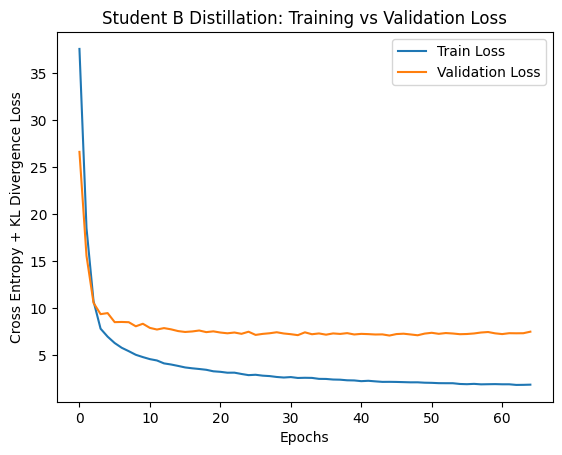

In [45]:
plt.plot(train_history, label="Train Loss")
plt.plot(test_history, label="Validation Loss")
plt.title("Student B Distillation: Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Cross Entropy + KL Divergence Loss")
plt.legend()
plt.show()

# Model Evaluation

In [56]:
MODEL_PATH  = Path(CWD) / "models"

os.makedirs(name=MODEL_PATH, exist_ok=True)

base_dir        = "bart_model"
fine_dir        = "fine_model"
student_a_dir   = "student_a_model"
student_b_dir   = "student_b_model"

base_path       = MODEL_PATH / base_dir
fine_path       = MODEL_PATH / fine_dir
student_a_path  = MODEL_PATH / student_a_dir
student_b_path  = MODEL_PATH / student_b_dir

In [57]:
base_model  = BartForConditionalGeneration.from_pretrained(base_path)
fine_model  = BartForConditionalGeneration.from_pretrained(fine_path)
student_a   = BartForConditionalGeneration.from_pretrained(student_a_path)
student_b   = BartForConditionalGeneration.from_pretrained(student_b_path)

models  = {
    "base_model":base_model,
    "fine_model":fine_model,
    "student_a":student_a,
    "student_b":student_b
}

datas   = {
    "raw":ABLATION_PATH / "raw.csv",
    "coref":ABLATION_PATH / "coref.csv",
    "textrank":ABLATION_PATH / "textrank.csv",
    "cftr":ABLATION_PATH / "coref+tr.csv"
}

In [58]:
results_dir     = "results"
results_path    = Path(CWD) / results_dir

bart_dir        = "bart"
fine_dir        = "fine"
student_a_dir   = "student-a"
student_b_dir   = "student-b"

bart_path       = results_path / bart_dir
fine_path       = results_path / fine_dir
student_a_path  = results_path / student_a_dir
student_b_path  = results_path / student_b_dir

os.makedirs(name=results_path, exist_ok=True)
os.makedirs(name=bart_path, exist_ok=True)
os.makedirs(name=fine_path, exist_ok=True)
os.makedirs(name=student_a_path, exist_ok=True)
os.makedirs(name=student_b_path, exist_ok=True)

In [59]:
saves   = {
    "base_model":bart_path,
    "fine_model":fine_path,
    "student_a":student_a_path,
    "student_b":student_b_path
}

In [61]:
raw_dataframe   = pd.read_csv(datas['raw'])

for data_name, data in datas.items():
    dataframe   = pd.read_csv(data)

    for model_name, model in models.items():
        model.to(device)
        model.eval()

        results = []

        for i, row in enumerate(tqdm(dataframe.itertuples(), total=len(dataframe))):
            raw_text    = raw_dataframe.loc[i, 'original_text']
            input_text  = row.original_text
            target      = row.reference_summary

            inputs  = base_tokenizer(
                text,
                return_tensors="pt",
                max_length=1024,
                truncation=True
            )
            inputs  = {k: v.to(device) for k, v in inputs.items()}

            with torch.no_grad():
                summary_ids = model.generate(
                    **inputs,
                    max_new_tokens=64,
                    min_new_tokens=10,
                    num_beams=2,
                    early_stopping=True
                )

                generated_summary = base_tokenizer.decode(
                    summary_ids[0],
                    skip_special_tokens=True
                )

                results.append({
                    "original_text": raw_text,
                    "input_text":input_text,
                    "generated_summary": generated_summary,
                    "reference_summary": target
                })
        
        results_df  = pd.DataFrame(results)
        save_path   = saves[model_name] / f"{data_name}.csv"
        results_df.to_csv(save_path, index=False)
        print(f"Saved: {model_name} - {data_name}")

  0%|          | 0/446 [00:00<?, ?it/s]

100%|██████████| 446/446 [03:04<00:00,  2.42it/s]


Saved: base_model - raw


100%|██████████| 446/446 [03:13<00:00,  2.31it/s]


Saved: fine_model - raw


...

Saved: fine_model - cftr


100%|██████████| 446/446 [01:55<00:00,  3.86it/s]


Saved: student_a - cftr


100%|██████████| 446/446 [02:01<00:00,  3.66it/s]

Saved: student_b - cftr


In [ ]:
from bert_score import score
import evaluate

In [ ]:
rouge   = evaluate.load('rouge')

result_files = {}

for k, v in saves.items():
    for file_path in saves[k].glob('*'):
        filename    = Path(file_path).stem
        result_files[f"{k}-{filename}"] = file_path

In [ ]:
evaluation_results = []

for file_name, file_path in result_files.items():

    print(f"\nEvaluating: {file_path.name}")

    df = pd.read_csv(file_path)

    # GET PREDICTIONS / REFERENCES
    predictions = (
        df["generated_summary"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    references = (
        df["reference_summary"]
        .fillna("")
        .astype(str)
        .tolist()
    )

    # ROUGE
    rouge_results = rouge.compute(
        predictions=predictions,
        references=references
    )

    # BERTSCORE
    P, R, F1 = score(
        predictions,
        references,
        lang="en",
        verbose=True
    )

    bertscore_precision = P.mean().item()
    bertscore_recall = R.mean().item()
    bertscore_f1 = F1.mean().item()

    # STORE RESULTS
    evaluation_results.append({
        "file": file_name,

        # ROUGE
        "rouge1": rouge_results["rouge1"],
        "rouge2": rouge_results["rouge2"],
        "rougeL": rouge_results["rougeL"],
        "rougeLsum": rouge_results["rougeLsum"],

        # BERTScore
        "bertscore_precision": bertscore_precision,
        "bertscore_recall": bertscore_recall,
        "bertscore_f1": bertscore_f1
    })

05/14/2026 19:29:55 - INFO - 	 Using default tokenizer.



Evaluating: cftr.csv


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


100%|██████████| 12/12 [00:01<00:00,  6.61it/s]


...

calculating scores...
computing bert embedding.


100%|██████████| 12/12 [00:01<00:00, 11.23it/s]


computing greedy matching.


100%|██████████| 7/7 [00:00<00:00, 82.35it/s]

done in 1.16 seconds, 384.70 sentences/sec


### Metrics
#### ROUGE
ROUGE measures lexical overlap between:
- generated summary
- reference (ground-truth) summary
Higher is better.

##### ROUGE-1
Measures overlap of single words (unigrams)

```
Reference:
the cat sat on the mat

Prediction:
the cat slept on mat
```

Shared words:
- the
- cat
- on
- mat

##### ROUGE-2
Measures overlap of 2-word sequences (bigrams)
```
Reference:
legal guardian agrees

Prediction:
guardian agrees behalf
```

Shared bigram:
- guardian agrees

##### ROUGE-L
Measures the longest common subsequence (LCS).

This evaluates:
- sentence-level structure
- ordering consistency
- coherent phrase progression

#### BERT Score
Measures semantic similarity using contextual embeddings from Transformers.  
This means:
- synonyms can still score highly
- paraphrases are rewarded.

```
Reference:
the parent agrees

Prediction:
the guardian consents
```

##### BERT Score Precision
Measures how much generated text is relevant

High precision means:
- generated words align semantically with the reference
- fewer hallucinations/extreneous tokens

##### BERT Score Recall
Measures how much reference information was captured

High recall means:
- the summary preserves important reference content

##### Bert Score F1
Harmonic mean of precision and recall. usually the main BERT Score metric that balances informativeness and relevance.

In [ ]:
save_dir    = Path(CWD) / "evaluation"
save_path   = save_dir / "evaluation_results.csv"
os.makedirs(name=save_dir, exist_ok=True)

evaluation_df = pd.DataFrame(evaluation_results)
evaluation_df.to_csv(save_path, index=False)

print("\nSaved evaluation results:")
print(save_path)

print("\nEvaluation Summary:")
print(evaluation_df.round(3).to_string())


Saved evaluation results:
d:\Documents\OneDrive - UTS\2026\42850 NLP Algorithms\Assignments\Assignment_2\NLP_Team5_Assignment3\evaluation\evaluation_results.csv

Evaluation Summary:
                   file  rouge1  rouge2  rougeL  rougeLsum  bertscore_precision  bertscore_recall  bertscore_f1
0       base_model-cftr   0.186   0.057   0.144      0.144                0.826             0.877         0.851
1      base_model-coref   0.188   0.058   0.145      0.145                0.827             0.878         0.851
2        base_model-raw   0.190   0.061   0.147      0.147                0.827             0.878         0.852
3   base_model-textrank   0.187   0.058   0.144      0.145                0.826             0.878         0.851
4       fine_model-cftr   0.247   0.136   0.209      0.210                0.839             0.899         0.868
5      fine_model-coref   0.253   0.145   0.217      0.217                0.840             0.901         0.869
6        fine_model-raw   0.254  